# Notebook 02: US Grid Statistics

**One Sensor, One Year — Edition 2: US Grid**

First numbers cold for the US48 + the top-10 BAs in 2025. Before drawing anything, we want to know:
- Per-fuel scale and volatility (CV%)
- Annual fuel mix
- Fossil vs clean split
- Battery storage behavior (signed: discharge positive, charge negative)
- Top-10 BA share of national generation — sets up the regional-contrast story arc

**Inputs:** `../data/processed/us48_2025_daily.csv`, `../data/processed/ba_2025_hourly.parquet` (from notebook 01)

**Output:** `../data/processed/us48_2025_stats.json`

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
YEAR = 2025

us48_daily = pd.read_csv(PROCESSED / f'us48_{YEAR}_daily.csv', parse_dates=['date'], index_col='date')
ba_long = pd.read_parquet(PROCESSED / f'ba_{YEAR}_hourly.parquet')
print(f'US48 daily: {us48_daily.shape}, columns: {us48_daily.columns.tolist()}')
print(f'BA long:    {ba_long.shape}, BAs: {sorted(ba_long["respondent"].unique())}')

# Fuel classification (EIA-930 has 16 codes; some are storage/variants of mainstream fuels)
STORAGE_COLS    = [c for c in ['BAT', 'UES', 'OES', 'PS'] if c in us48_daily.columns]
FOSSIL_COLS     = [c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in us48_daily.columns]
CLEAN_COLS      = [c for c in ['NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB'] if c in us48_daily.columns]
UNCLASSIFIED    = [c for c in ['UNK'] if c in us48_daily.columns]
GEN_COLS        = FOSSIL_COLS + CLEAN_COLS + UNCLASSIFIED  # excludes storage from generation total

FUEL_COLORS = {
    'COL': '#D4890E', 'NG': '#F0C078', 'NUC': '#2A9D8F', 'WND': '#72B352',
    'SUN': '#F4C430', 'WAT': '#264653', 'OTH': '#9B72CF', 'BAT': '#A0A0A0',
    'UES': '#C0C0C0', 'OES': '#B8B8B8', 'PS':  '#7090A8', 'OIL': '#5A3825',
    'GEO': '#A0524D', 'SNB': '#FFE066', 'WNB': '#9DC183', 'UNK': '#777777',
}
FUEL_LABELS = {
    'COL': 'Coal', 'NG': 'Natural Gas', 'NUC': 'Nuclear', 'WND': 'Wind',
    'SUN': 'Solar', 'WAT': 'Hydro', 'OTH': 'Other', 'BAT': 'Battery',
    'UES': 'Unknown Storage', 'OES': 'Other Storage', 'PS': 'Pumped Storage',
    'OIL': 'Oil', 'GEO': 'Geothermal', 'SNB': 'Solar (subcat)', 'WNB': 'Wind (subcat)',
    'UNK': 'Unknown',
}

print(f'\nGeneration fuels ({len(GEN_COLS)}): {GEN_COLS}')
print(f'Storage cols ({len(STORAGE_COLS)}):     {STORAGE_COLS}')
print(f'Fossil:           {FOSSIL_COLS}')
print(f'Clean:            {CLEAN_COLS}')
print(f'Unclassified:     {UNCLASSIFIED}')

US48 daily: (365, 16), columns: ['BAT', 'COL', 'GEO', 'NG', 'NUC', 'OES', 'OIL', 'OTH', 'PS', 'SNB', 'SUN', 'UES', 'UNK', 'WAT', 'WNB', 'WND']
BA long:    (808277, 4), BAs: ['BPAT', 'CISO', 'ERCO', 'ISNE', 'MISO', 'NYIS', 'PJM', 'SOCO', 'SWPP', 'TVA']

Generation fuels (12): ['COL', 'NG', 'OIL', 'OTH', 'NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB', 'UNK']
Storage cols (4):     ['BAT', 'UES', 'OES', 'PS']
Fossil:           ['COL', 'NG', 'OIL', 'OTH']
Clean:            ['NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB']
Unclassified:     ['UNK']


## 1. Summary statistics table

Per-fuel descriptive stats (MWh/day). Annual TWh, share of total generation, and CV (coefficient of variation) — a unitless volatility metric where <15% is "metronome" and >50% is "wild".

In [2]:
stats = us48_daily[GEN_COLS].describe().T
stats['annual_TWh'] = (us48_daily[GEN_COLS].sum() / 1e6).round(1)
stats['share_%'] = (us48_daily[GEN_COLS].sum() / us48_daily[GEN_COLS].sum().sum() * 100).round(2)
stats['cv_%'] = (stats['std'] / stats['mean'] * 100).round(1)
stats = stats[['mean', 'std', 'cv_%', 'min', '25%', '50%', '75%', 'max', 'share_%', 'annual_TWh']]
stats.columns = ['Mean', 'Std', 'CV %', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Share %', 'Annual TWh']
stats.index = [FUEL_LABELS.get(c, c) for c in stats.index]
stats = stats.round(0)

print(f'US48 {YEAR} — Daily Generation Statistics (MWh/day)')
print('=' * 110)
print(stats.to_string())

total_annual_twh = us48_daily[GEN_COLS].sum().sum() / 1e6
total_daily_mean = us48_daily[GEN_COLS].sum(axis=1).mean()
print(f'\nTotal daily mean: {total_daily_mean:,.0f} MWh/day')
print(f'Total annual:     {total_annual_twh:,.0f} TWh')

US48 2025 — Daily Generation Statistics (MWh/day)
                     Mean       Std   CV %        Min         Q1     Median         Q3        Max  Share %  Annual TWh
Coal            2059476.0  457241.0   22.0  1322231.0  1685641.0  1973349.0  2396089.0  3317382.0     18.0       752.0
Natural Gas     4623979.0  937182.0   20.0  2840022.0  3886795.0  4471697.0  5347080.0  7037106.0     40.0      1688.0
Oil               21417.0   25721.0  120.0     4720.0    10227.0    13859.0    21839.0   261458.0      0.0         8.0
Other            133976.0   22743.0   17.0    86674.0   116654.0   134214.0   148176.0   200991.0      1.0        49.0
Nuclear         2155825.0  155799.0    7.0  1845057.0  2037989.0  2186380.0  2287639.0  2378477.0     18.0       787.0
Wind            1269465.0  388776.0   31.0   405455.0   983442.0  1260718.0  1559671.0  2219868.0     11.0       463.0
Solar            732176.0  201511.0   28.0   297299.0   537464.0   782826.0   911528.0  1059007.0      6.0       267.

## 2. Volatility — who is the metronome, who is the wildcard?

CV = std / mean × 100%. Flattens scale so a 1500 TWh fuel and a 30 TWh fuel can be compared on the same axis.

/tmp/ipykernel_50033/754318786.py:4: RuntimeWarning: invalid value encountered in scalar divide
  'cv': [us48_daily[c].std() / us48_daily[c].mean() * 100 for c in GEN_COLS],


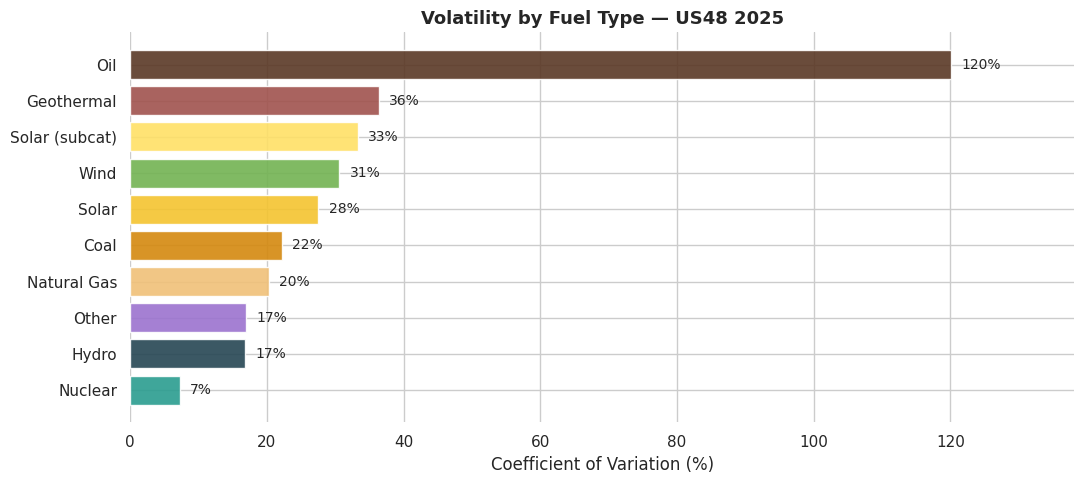

In [3]:
cv_data = (
    pd.DataFrame({
        'fuel': [FUEL_LABELS.get(c, c) for c in GEN_COLS],
        'cv': [us48_daily[c].std() / us48_daily[c].mean() * 100 for c in GEN_COLS],
        'color': [FUEL_COLORS.get(c, '#888') for c in GEN_COLS],
    })
    .sort_values('cv', ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cv_data['fuel'], cv_data['cv'], color=cv_data['color'], alpha=0.9)
for bar, val in zip(bars, cv_data['cv']):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title(f'Volatility by Fuel Type — US48 {YEAR}', fontsize=13, fontweight='bold')
ax.set_xlim(0, cv_data['cv'].max() * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 3. Annual mix — how the pie slices

Share of total US48 generation by fuel.

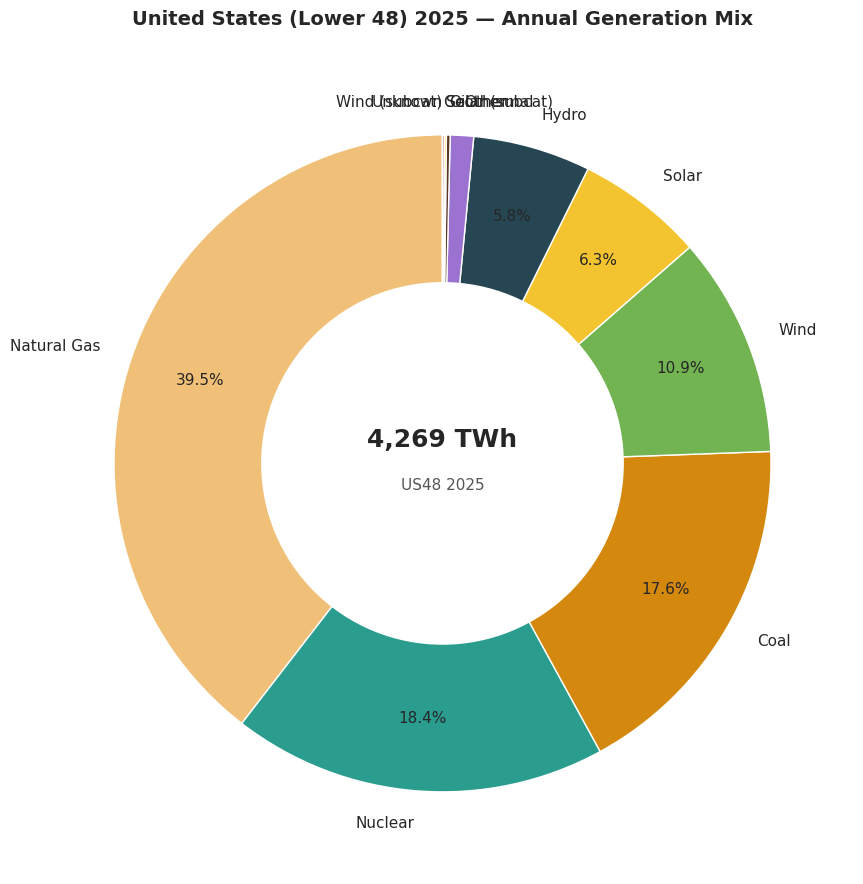


Annual share by fuel (%):
  Natural Gas       : 39.54%
  Nuclear           : 18.43%
  Coal              : 17.61%
  Wind              : 10.85%
  Solar             :  6.26%
  Hydro             :  5.79%
  Other             :  1.15%
  Oil               :  0.18%
  Solar (subcat)    :  0.10%
  Geothermal        :  0.09%
  Wind (subcat)     :  0.00%
  Unknown           :  0.00%


In [4]:
annual = us48_daily[GEN_COLS].sum().sort_values(ascending=False)
annual_share = (annual / annual.sum() * 100)

fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(
    annual.values,
    labels=[FUEL_LABELS.get(c, c) for c in annual.index],
    colors=[FUEL_COLORS.get(c, '#888') for c in annual.index],
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 1.5 else '',
    startangle=90,
    pctdistance=0.78,
    textprops={'fontsize': 11},
)
centre = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre)
ax.text(0, 0.05, f'{annual.sum()/1e6:,.0f} TWh', ha='center', fontsize=18, fontweight='bold')
ax.text(0, -0.08, f'US48 {YEAR}', ha='center', fontsize=11, color='#555')
ax.set_title(f'United States (Lower 48) {YEAR} — Annual Generation Mix',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(PROCESSED / f'us48_{YEAR}_donut.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nAnnual share by fuel (%):')
for fuel, share in annual_share.items():
    print(f'  {FUEL_LABELS.get(fuel, fuel):18s}: {share:5.2f}%')

## 4. Fossil vs clean — the big split

**Fossil:** COL + NG + OIL + OTH (OTH includes biomass/landfill/waste, lumped here as conservative read).  
**Clean:** NUC + WND + SUN + WAT + GEO.  

Notebook 03 will give each fuel its own CO₂ factor for the real accounting.

Fossil (COL+NG+OIL+OTH):  2496.2 TWh  ( 58.5%)
Clean  (NUC+WND+SUN+WAT+GEO+SNB+WNB):  1772.6 TWh  ( 41.5%)

Cleanest day: April 13 — 55.8% clean
Dirtiest day: August 19 — 31.7% clean


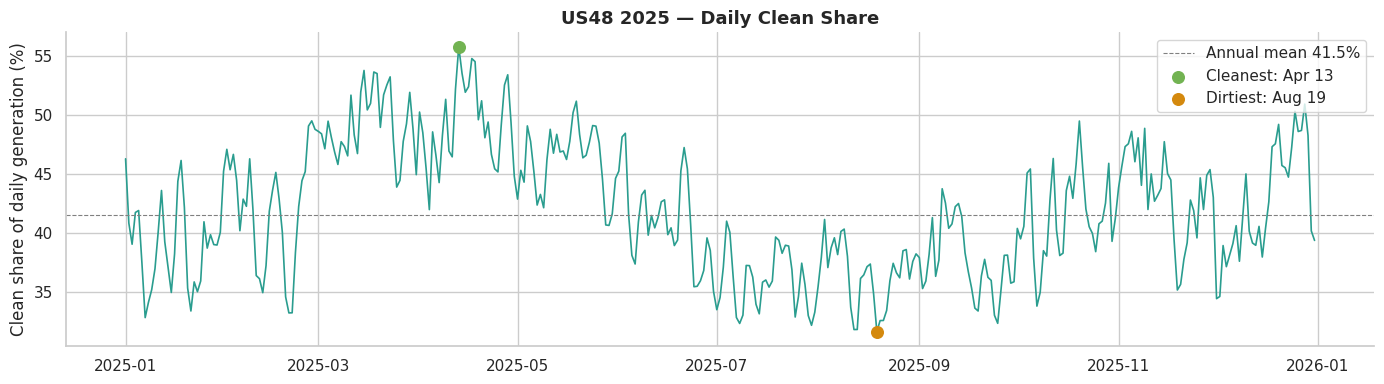

In [5]:
fossil_daily = us48_daily[FOSSIL_COLS].sum(axis=1)
clean_daily = us48_daily[CLEAN_COLS].sum(axis=1)
gen_daily = us48_daily[GEN_COLS].sum(axis=1)

fossil_share = fossil_daily.sum() / gen_daily.sum() * 100
clean_share = clean_daily.sum() / gen_daily.sum() * 100

print(f'Fossil ({"+".join(FOSSIL_COLS)}): {fossil_daily.sum()/1e6:>7.1f} TWh  ({fossil_share:5.1f}%)')
print(f'Clean  ({"+".join(CLEAN_COLS)}): {clean_daily.sum()/1e6:>7.1f} TWh  ({clean_share:5.1f}%)')

clean_pct_daily = clean_daily / gen_daily * 100
best_idx = clean_pct_daily.idxmax()
worst_idx = clean_pct_daily.idxmin()
print(f'\nCleanest day: {best_idx.strftime("%B %d")} — {clean_pct_daily.loc[best_idx]:.1f}% clean')
print(f'Dirtiest day: {worst_idx.strftime("%B %d")} — {clean_pct_daily.loc[worst_idx]:.1f}% clean')

# Annotated daily clean-% time series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(clean_pct_daily.index, clean_pct_daily.values, color='#2A9D8F', linewidth=1.2)
ax.axhline(clean_share, color='gray', linestyle='--', linewidth=0.8, label=f'Annual mean {clean_share:.1f}%')
ax.scatter([best_idx], [clean_pct_daily.loc[best_idx]], color='#72B352', zorder=5, s=70, label=f'Cleanest: {best_idx.strftime("%b %d")}')
ax.scatter([worst_idx], [clean_pct_daily.loc[worst_idx]], color='#D4890E', zorder=5, s=70, label=f'Dirtiest: {worst_idx.strftime("%b %d")}')
ax.set_ylabel('Clean share of daily generation (%)')
ax.set_title(f'US48 {YEAR} — Daily Clean Share', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Battery storage — net charging vs discharging

EIA-930 BAT is signed: positive = discharge to grid, negative = charging. Roll up to daily net flow.

(Texas's ERCOT WSL is opposite-signed — comparable concept though.)

Battery storage (BAT) daily net — positive = net discharge, negative = net charge
  Net discharge days:  364  (100%)
  Net charge days:       1  (0%)
  Zero days:             0
  Most-discharge day: November 25 (+38.4 GWh)
  Most-charge day:    December 25 (-2.7 GWh)
  Mean daily:         +20.3 GWh


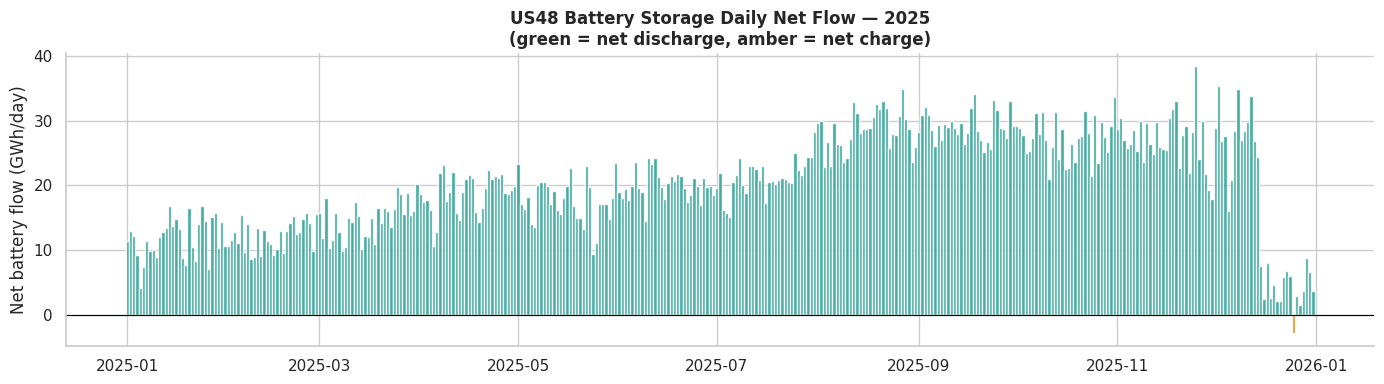

In [6]:
if 'BAT' in us48_daily.columns:
    bat = us48_daily['BAT']
    net_discharge_days = int((bat > 0).sum())
    net_charge_days = int((bat < 0).sum())
    net_zero_days = int((bat == 0).sum())

    print('Battery storage (BAT) daily net — positive = net discharge, negative = net charge')
    print(f'  Net discharge days: {net_discharge_days:4d}  ({net_discharge_days/len(bat)*100:.0f}%)')
    print(f'  Net charge days:    {net_charge_days:4d}  ({net_charge_days/len(bat)*100:.0f}%)')
    print(f'  Zero days:          {net_zero_days:4d}')
    print(f'  Most-discharge day: {bat.idxmax().strftime("%B %d")} ({bat.max()/1e3:+,.1f} GWh)')
    print(f'  Most-charge day:    {bat.idxmin().strftime("%B %d")} ({bat.min()/1e3:+,.1f} GWh)')
    print(f'  Mean daily:         {bat.mean()/1e3:+.1f} GWh')

    fig, ax = plt.subplots(figsize=(14, 4))
    colors_ = ['#2A9D8F' if v >= 0 else '#D4890E' for v in bat.values]
    ax.bar(bat.index, bat.values / 1e3, color=colors_, width=1.0, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Net battery flow (GWh/day)')
    ax.set_title(f'US48 Battery Storage Daily Net Flow — {YEAR}\n(green = net discharge, amber = net charge)',
                 fontsize=12, fontweight='bold')
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('No BAT column in US48 daily — skipping')

## 6. Top-10 BA share of US48 generation

How concentrated is US generation across the largest balancing authorities? Sets up the regional-contrast story arc — which BAs deserve focus, which fuels each is dominated by.

Top-10 BAs — annual TWh (2025)
fueltype    BAT    COL  GEO     NG    NUC  OES  OIL   OTH   PS  SNB   SUN  UES  UNK   WAT  WNB    WND  Total  % of US48
respondent                                                                                                             
PJM         0.0  145.8  0.0  366.5  270.8  0.0  5.3  12.6  0.0  0.0  24.7  0.0  0.0  15.5  0.0   32.1  873.5       20.5
MISO       -0.1  192.1  0.0  233.2   91.7  0.0  0.0   3.7  0.0  0.0  29.8  0.0  0.0   9.9  0.0   99.0  659.1       15.4
ERCO        5.1   63.2  0.0  199.6   41.9  0.0  0.0   0.4  0.0  0.0  67.5 -6.4  0.0   0.5  0.0  114.8  486.8       11.4
SWPP        0.0   87.6  0.0   75.9   16.2  0.0  0.0   0.6  0.0  0.0   2.4  0.0  0.0   8.8  0.0  111.0  302.5        7.1
SOCO       -0.0   44.1  0.0  125.5   64.2  0.0  0.0   1.9 -0.5  0.7  10.0  0.0  0.0   5.9  0.0    0.0  251.8        5.9
CISO        0.0   -0.0  0.3   79.0   17.6  0.0  0.4  -1.7  0.0  0.0  49.7  0.0  0.0  21.3  0.0   19.8  186.3        4.4
TVA      

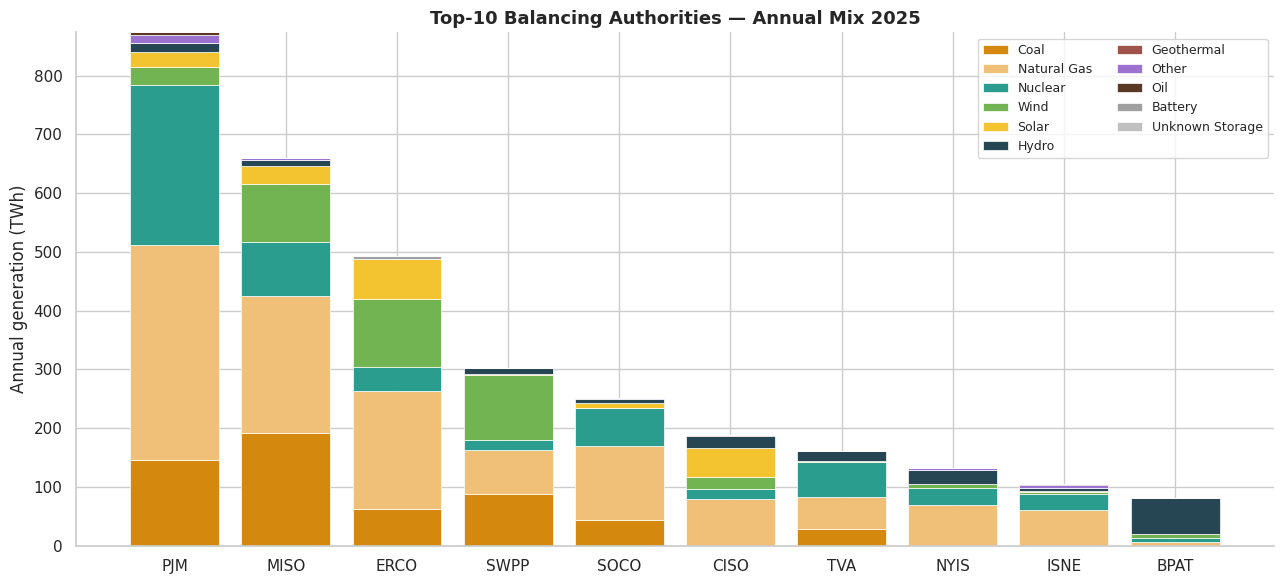

In [7]:
ba_annual = (ba_long
    .groupby(['respondent', 'fueltype'])['value_mwh']
    .sum()
    .div(1e6)  # MWh -> TWh
    .unstack(fill_value=0))
ba_annual['Total'] = ba_annual.sum(axis=1)
ba_annual = ba_annual.sort_values('Total', ascending=False)
us48_total = us48_daily[GEN_COLS].sum().sum() / 1e6
ba_annual['% of US48'] = (ba_annual['Total'] / us48_total * 100).round(1)

print(f'Top-10 BAs — annual TWh ({YEAR})')
print('=' * 90)
print(ba_annual.round(1).to_string())
print(f'\nTop-10 BAs combined: {ba_annual["Total"].sum():,.0f} TWh')
print(f'US48 reference:      {us48_total:,.0f} TWh')
print(f'Coverage:            {ba_annual["Total"].sum() / us48_total * 100:.1f}% of US48')

# Stacked bar: annual TWh per BA, colored by fuel
fuel_order_in_data = [c for c in ['COL', 'NG', 'NUC', 'WND', 'SUN', 'WAT', 'GEO', 'OTH', 'OIL', 'BAT', 'UES']
                       if c in ba_annual.columns]
stack = ba_annual[fuel_order_in_data].clip(lower=0)
fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(stack))
for fuel in fuel_order_in_data:
    ax.bar(stack.index, stack[fuel].values, bottom=bottom,
           color=FUEL_COLORS.get(fuel, '#888'), label=FUEL_LABELS.get(fuel, fuel),
           edgecolor='white', linewidth=0.5)
    bottom += stack[fuel].values
ax.set_ylabel('Annual generation (TWh)')
ax.set_title(f'Top-10 Balancing Authorities — Annual Mix {YEAR}', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', ncol=2, frameon=True, fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / f'top10_BAs_{YEAR}.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save stats JSON

Compact JSON blob downstream notebooks and the eventual web build can read without re-parsing the daily CSV.

In [8]:
stats_out = {
    'year': YEAR,
    'grid': 'US48',
    'source': 'EIA-930 v2 API (electricity/rto/fuel-type-data)',
    'days': int(len(us48_daily)),
    'total_annual_twh': round(total_annual_twh, 1),
    'total_daily_mean_mwh': round(total_daily_mean, 0),
    'annual_share_pct': {k: round(float(v), 2) for k, v in annual_share.items()},
    'annual_twh': {k: round(float(us48_daily[k].sum() / 1e6), 2) for k in GEN_COLS},
    'cv_pct': {k: round(float(us48_daily[k].std() / us48_daily[k].mean() * 100), 1) for k in GEN_COLS},
    'fossil_share_pct': round(float(fossil_share), 1),
    'clean_share_pct': round(float(clean_share), 1),
    'cleanest_day': {'date': best_idx.strftime('%Y-%m-%d'), 'clean_pct': round(float(clean_pct_daily.loc[best_idx]), 1)},
    'dirtiest_day': {'date': worst_idx.strftime('%Y-%m-%d'), 'clean_pct': round(float(clean_pct_daily.loc[worst_idx]), 1)},
    'top_10_bas': {
        ba: {
            'annual_twh': round(float(ba_annual.loc[ba, 'Total']), 1),
            'share_of_us48_pct': round(float(ba_annual.loc[ba, '% of US48']), 1),
        }
        for ba in ba_annual.index
    },
    'top_10_combined_share_pct': round(float(ba_annual['Total'].sum() / us48_total * 100), 1),
}

if 'BAT' in us48_daily.columns:
    stats_out['battery'] = {
        'net_discharge_days': net_discharge_days,
        'net_charge_days': net_charge_days,
        'most_discharge_day': bat.idxmax().strftime('%Y-%m-%d'),
        'most_charge_day': bat.idxmin().strftime('%Y-%m-%d'),
        'mean_net_mwh': round(float(bat.mean()), 0),
    }

out_path = PROCESSED / f'us48_{YEAR}_stats.json'
with open(out_path, 'w') as f:
    json.dump(stats_out, f, indent=2)
print(f'Wrote {out_path.name}')
print(json.dumps(stats_out, indent=2))

Wrote us48_2025_stats.json
{
  "year": 2025,
  "grid": "US48",
  "source": "EIA-930 v2 API (electricity/rto/fuel-type-data)",
  "days": 365,
  "total_annual_twh": 4268.7,
  "total_daily_mean_mwh": 11695191.0,
  "annual_share_pct": {
    "NG": 39.54,
    "NUC": 18.43,
    "COL": 17.61,
    "WND": 10.85,
    "SUN": 6.26,
    "WAT": 5.79,
    "OTH": 1.15,
    "OIL": 0.18,
    "SNB": 0.1,
    "GEO": 0.09,
    "WNB": 0.0,
    "UNK": 0.0
  },
  "annual_twh": {
    "COL": 751.71,
    "NG": 1687.75,
    "OIL": 7.82,
    "OTH": 48.9,
    "NUC": 786.88,
    "WND": 463.35,
    "SUN": 267.24,
    "WAT": 246.98,
    "GEO": 4.05,
    "SNB": 4.06,
    "WNB": 0.0,
    "UNK": 0.0
  },
  "cv_pct": {
    "COL": 22.2,
    "NG": 20.3,
    "OIL": 120.1,
    "OTH": 17.0,
    "NUC": 7.2,
    "WND": 30.6,
    "SUN": 27.5,
    "WAT": 16.8,
    "GEO": 36.4,
    "SNB": 33.3,
    "WNB": NaN,
    "UNK": NaN
  },
  "fossil_share_pct": 58.5,
  "clean_share_pct": 41.5,
  "cleanest_day": {
    "date": "2025-04-13",
   

/tmp/ipykernel_50033/3988557945.py:10: RuntimeWarning: invalid value encountered in scalar divide
  'cv_pct': {k: round(float(us48_daily[k].std() / us48_daily[k].mean() * 100), 1) for k in GEN_COLS},


## Key findings (fill in after first run)

1. US48 total generation 2025 ≈ ~4,200 TWh (expected; fill exact after run).
2. Natural gas dominates — likely ~40% (vs Texas's ~45% gas, vs India's ~3% gas).
3. Top-10 BAs cover ~85% of US48 generation — the regional story is mostly told through these.
4. PJM and MISO are the two giants; SPP and ERCO are the wind-heavy mid-tier.
5. Battery storage is now a daily participant nationally — net-discharge days are common.

**Compare to other editions:**
- Ed1 India 2024: 1,700 TWh, 73% coal, ~6% renewables
- Texas 2025: 495 TWh, 53% gas, 37% wind+solar
- US48 2025: ~4,200 TWh, ~40% gas, ~25% renewables

→ Next: Notebook 03 — Emissions & Intensity (eGRID factors per fuel)